# Hack-O-Week | Week 3 & 4: Python, NumPy, Pandas, Visualization
1. **Python essentials:** functions, OOP, list/dict comprehensions
2. **NumPy:** arrays, broadcasting, vectorized ops
3. **Pandas:** dataframes, cleaning, merging, groupby
4. **Data visualization:** Matplotlib, Seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.set_printoptions(precision=3, suppress=True)
sns.set_theme(style="whitegrid")

## Part 1: Python Essentials
### 1.1 Functions

In [2]:
def grade(score, pass_mark=40):
    """Return a letter grade for a score."""
    if score >= 75: return "A"
    if score >= 60: return "B"
    if score >= pass_mark: return "C"
    return "F"

def stats(*nums, **opts):
    """*args collects positionals, **kwargs collects keywords."""
    total = sum(nums)
    return {"n": len(nums), "total": total, "mean": round(total / len(nums), opts.get("ndigits", 2))}

square = lambda x: x ** 2
print(grade(82), grade(55), grade(20))
print(stats(10, 20, 30, ndigits=1))
print(list(map(square, [1, 2, 3])))

A C F
{'n': 3, 'total': 60, 'mean': 20.0}
[1, 4, 9]


### 1.2 Object-Oriented Programming
Classes bundle **data** (attributes) and **behaviour** (methods). Inheritance reuses and specialises.

In [3]:
class Student:
    count = 0                                   # class attribute
    def __init__(self, name, marks):
        self.name, self.marks = name, marks     # instance attributes
        Student.count += 1
    def average(self):
        return sum(self.marks) / len(self.marks)
    def __repr__(self):
        return f"Student({self.name!r}, avg={self.average():.1f})"

class HonorsStudent(Student):                   # inheritance
    def average(self):                          # method overriding
        return super().average() + 5            # bonus

s1 = Student("Asha", [70, 80, 90])
s2 = HonorsStudent("Ravi", [60, 70, 80])
print(s1, s2, "| total students:", Student.count)

Student('Asha', avg=80.0) Student('Ravi', avg=75.0) | total students: 2


### 1.3 List and dict comprehensions

In [4]:
nums = range(1, 11)
squares   = [n**2 for n in nums]
evens_sq  = [n**2 for n in nums if n % 2 == 0]
sq_map    = {n: n**2 for n in nums if n <= 5}
words     = ["data", "science", "python", "ml"]
lengths   = {w: len(w) for w in words}
unique_len = {len(w) for w in words}            # set comprehension
flat = [x for row in [[1, 2], [3, 4], [5]] for x in row]

print(squares); print(evens_sq); print(sq_map); print(lengths); print(unique_len); print(flat)

[1, 4, 9, 16, 25, 36, 49, 64, 81, 100]
[4, 16, 36, 64, 100]
{1: 1, 2: 4, 3: 9, 4: 16, 5: 25}
{'data': 4, 'science': 7, 'python': 6, 'ml': 2}
{2, 4, 6, 7}
[1, 2, 3, 4, 5]


## Part 2: NumPy
### 2.1 Arrays

In [5]:
a = np.array([1, 2, 3, 4, 5, 6])
M = a.reshape(2, 3)
print("shape:", M.shape, "| dtype:", M.dtype, "| ndim:", M.ndim)
print("zeros:\n", np.zeros((2, 2)), "\nlinspace:", np.linspace(0, 1, 5), "\narange:", np.arange(0, 10, 3))
print("slice M[:, 1:] =\n", M[:, 1:])
print("boolean mask a[a>3] =", a[a > 3])
print("column sums:", M.sum(axis=0), "| row means:", M.mean(axis=1))

shape: (2, 3) | dtype: int64 | ndim: 2
zeros:
 [[0. 0.]
 [0. 0.]] 
linspace: [0.   0.25 0.5  0.75 1.  ] 
arange: [0 3 6 9]
slice M[:, 1:] =
 [[2 3]
 [5 6]]
boolean mask a[a>3] = [4 5 6]
column sums: [5 7 9] | row means: [2. 5.]


### 2.2 Broadcasting
NumPy stretches smaller arrays to match larger ones **without copying**, provided shapes are compatible (compared from the right: equal or 1).

In [6]:
X = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])      # (3,3)
row = np.array([10, 20, 30])                          # (3,)  -> acts like (1,3)
col = np.array([[100], [200], [300]])                 # (3,1)
print("X + row:\n", X + row)
print("X + col:\n", X + col)
print("col + row -> outer-sum shape", (col + row).shape)

# practical use: standardise every column of a dataset
data = np.random.default_rng(1).normal(50, 10, size=(5, 3))
z = (data - data.mean(axis=0)) / data.std(axis=0)
print("column means after standardising:", z.mean(axis=0).round(6))

X + row:
 [[11 22 33]
 [14 25 36]
 [17 28 39]]
X + col:
 [[101 102 103]
 [204 205 206]
 [307 308 309]]
col + row -> outer-sum shape (3, 3)
column means after standardising: [-0. -0.  0.]


### 2.3 Vectorised operations
Avoid Python loops. Whole-array operations run in compiled C and are much faster.

In [7]:
import time
big = np.random.default_rng(0).random(1_000_000)

t = time.perf_counter(); loop = [x * 2 + 1 for x in big]; t_loop = time.perf_counter() - t
t = time.perf_counter(); vec = big * 2 + 1;               t_vec = time.perf_counter() - t
print(f"loop: {t_loop*1000:.1f} ms | vectorised: {t_vec*1000:.2f} ms | speed-up: ~{t_loop/t_vec:.0f}x")

print("np.where:", np.where(np.array([5, 50, 90]) >= 60, "pass", "fail"))
print("cumsum:", np.cumsum([1, 2, 3, 4]), "| argmax:", np.argmax([3, 9, 2]))

loop: 146.3 ms | vectorised: 3.88 ms | speed-up: ~38x
np.where: ['fail' 'fail' 'pass']
cumsum: [ 1  3  6 10] | argmax: 1


## Part 3: Pandas
### 3.1 DataFrames

In [8]:
rng = np.random.default_rng(42)
n = 60
students = pd.DataFrame({
    "student_id": range(1, n + 1),
    "name": [f"Student{i}" for i in range(1, n + 1)],
    "branch": rng.choice(["CS", "AI", "IT", "ENTC"], n),
    "gender": rng.choice(["F", "M"], n),
    "study_hours": rng.normal(5, 2, n).round(1),
    "attendance": rng.normal(80, 10, n).round(1),
})
students["marks"] = (35 + 6 * students.study_hours + 0.2 * students.attendance + rng.normal(0, 6, n)).clip(upper=100).round(1)

# introduce realistic mess
students.loc[rng.choice(n, 6, replace=False), "marks"] = np.nan
students.loc[rng.choice(n, 4, replace=False), "attendance"] = np.nan
students.loc[[3, 10], "study_hours"] = [-2.0, 40.0]            # impossible values
students = pd.concat([students, students.iloc[[0, 1]]])         # duplicate rows

print(students.shape); students.head()

(62, 7)


,student_id,name,branch,gender,study_hours,attendance,marks
0,1,Student1,CS,M,3.3,96.0,73.3
1,2,Student2,ENTC,M,6.9,77.6,93.6
2,3,Student3,IT,F,1.6,69.8,66.4
3,4,Student4,AI,M,-2.0,81.8,78.5
4,5,Student5,AI,F,5.3,82.2,80.8


In [9]:
print(students.info())
students.describe().round(2)

<class 'pandas.DataFrame'>
Index: 62 entries, 0 to 1
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   student_id   62 non-null     int64  
 1   name         62 non-null     str    
 2   branch       62 non-null     str    
 3   gender       62 non-null     str    
 4   study_hours  62 non-null     float64
 5   attendance   58 non-null     float64
 6   marks        56 non-null     float64
dtypes: float64(3), int64(1), str(3)
memory usage: 3.9 KB
None


,student_id,study_hours,attendance,marks
count,62.00,62.00,58.00,56.00
mean,29.56,5.04,80.10,79.05
std,17.94,4.83,10.38,10.18
min,1.00,-2.00,63.30,52.70
25%,14.25,3.30,71.82,73.18
50%,29.50,4.50,78.40,79.35
75%,44.75,5.90,85.93,85.00
max,60.00,40.00,109.10,100.00


### 3.2 Cleaning
Duplicates, missing values, and impossible values are the three classic problems.

In [10]:
df = students.copy()
print("duplicates:", df.duplicated().sum()); df = df.drop_duplicates()
print("missing before:\n", df.isna().sum()[df.isna().sum() > 0])

df["attendance"] = df["attendance"].fillna(df["attendance"].median())     # impute
df = df.dropna(subset=["marks"])                                            # drop unlabeled
df = df[df["study_hours"].between(0, 16)]                                   # remove impossible
df["branch"] = df["branch"].astype("category")
df["result"] = np.where(df["marks"] >= 60, "Pass", "Needs Work")
print("clean shape:", df.shape, "| missing left:", int(df.isna().sum().sum()))

duplicates: 2
missing before:
 attendance    4
marks         6
dtype: int64
clean shape: (52, 8) | missing left: 0


### 3.3 Merging
`merge` joins tables on a key, like SQL JOIN.

In [11]:
branches = pd.DataFrame({
    "branch": ["CS", "AI", "IT", "ENTC"],
    "hod": ["Dr. Rao", "Dr. Iyer", "Dr. Khan", "Dr. Joshi"],
    "intake": [120, 60, 60, 90],
})
merged = df.merge(branches, on="branch", how="left")
print(merged[["name", "branch", "hod", "intake"]].head())

# inner vs left vs outer
left = pd.DataFrame({"k": [1, 2, 3], "a": ["x", "y", "z"]})
right = pd.DataFrame({"k": [2, 3, 4], "b": ["p", "q", "r"]})
for how in ["inner", "left", "outer"]:
    print(f"\n{how}:\n", left.merge(right, on="k", how=how))

       name branch        hod  intake
0  Student1     CS    Dr. Rao     120
1  Student2   ENTC  Dr. Joshi      90
2  Student3     IT   Dr. Khan      60
3  Student5     AI   Dr. Iyer      60
4  Student6   ENTC  Dr. Joshi      90

inner:
    k  a  b
0  2  y  p
1  3  z  q

left:
    k  a    b
0  1  x  NaN
1  2  y    p
2  3  z    q

outer:
    k    a    b
0  1    x  NaN
1  2    y    p
2  3    z    q
3  4  NaN    r


### 3.4 Groupby
**Split → apply → combine.**

In [12]:
g = merged.groupby("branch", observed=True).agg(
    students=("student_id", "count"),
    avg_marks=("marks", "mean"),
    avg_hours=("study_hours", "mean"),
    best=("marks", "max"),
).round(2).sort_values("avg_marks", ascending=False)
print(g)
print()
print(merged.pivot_table(values="marks", index="branch", columns="gender", aggfunc="mean", observed=True).round(1))

        students  avg_marks  avg_hours   best
branch                                       
ENTC          15      80.94       4.63   97.6
IT            13      78.57       4.26  100.0
CS            13      78.52       4.67   94.0
AI            11      76.68       4.67   96.6

gender     F     M
branch            
AI      79.2  74.6
CS      77.4  79.5
ENTC    82.1  80.2
IT      78.8  78.0


## Part 4: Data Visualization
### 4.1 Matplotlib (full control)

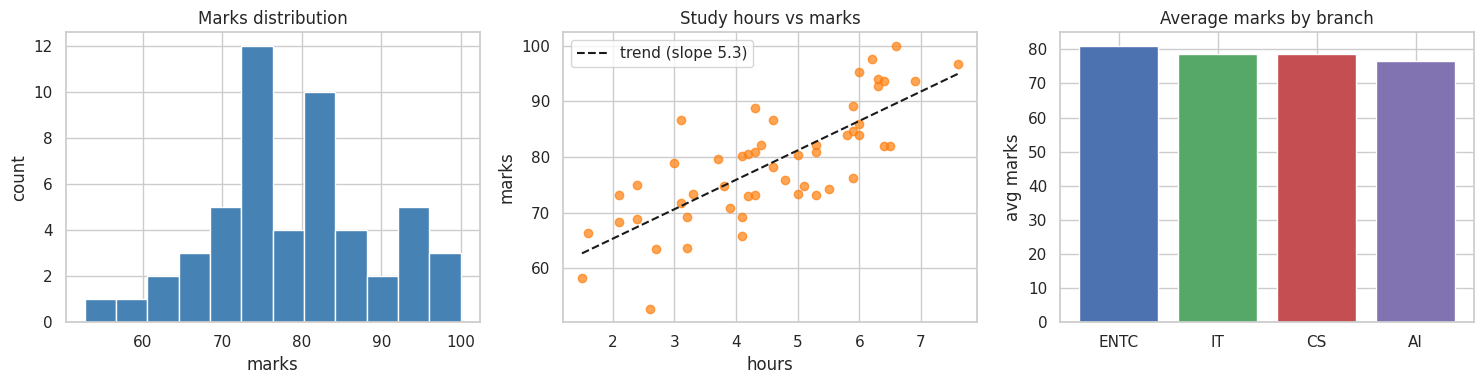

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].hist(merged["marks"], bins=12, color="steelblue", edgecolor="white")
axs[0].set(title="Marks distribution", xlabel="marks", ylabel="count")

axs[1].scatter(merged["study_hours"], merged["marks"], alpha=.7, c="tab:orange")
m, c0 = np.polyfit(merged["study_hours"], merged["marks"], 1)
xs = np.linspace(merged["study_hours"].min(), merged["study_hours"].max(), 50)
axs[1].plot(xs, m * xs + c0, "k--", label=f"trend (slope {m:.1f})")
axs[1].set(title="Study hours vs marks", xlabel="hours", ylabel="marks"); axs[1].legend()

axs[2].bar(g.index.astype(str), g["avg_marks"], color=["#4c72b0", "#55a868", "#c44e52", "#8172b2"])
axs[2].set(title="Average marks by branch", ylabel="avg marks")
plt.tight_layout(); plt.show()

### 4.2 Seaborn (statistical plots, less code)

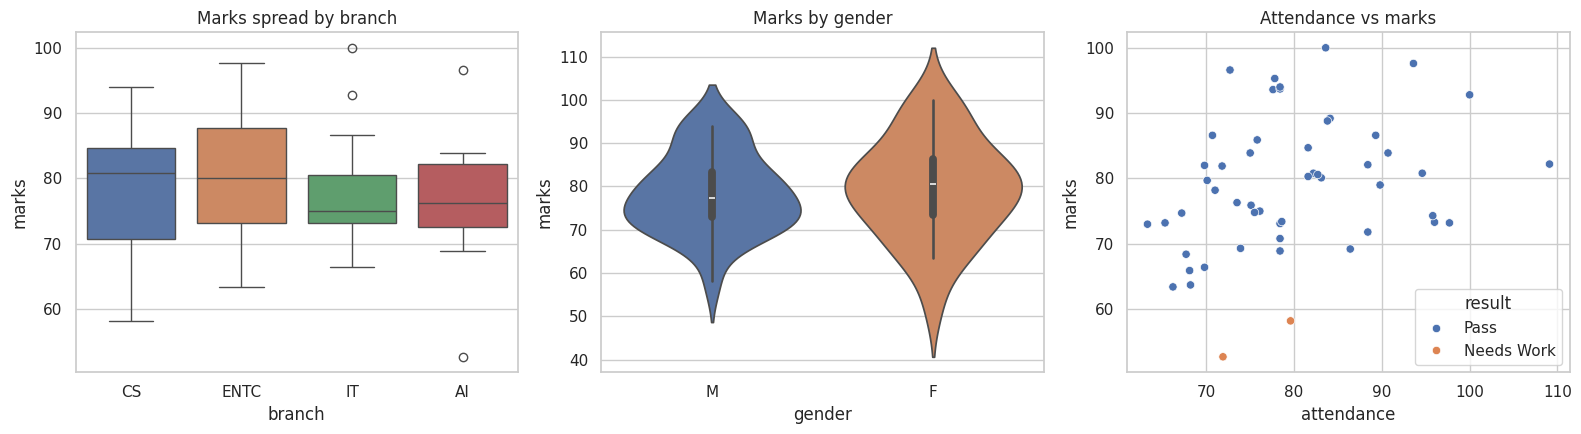

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(data=merged, x="branch", y="marks", hue="branch", ax=axs[0], legend=False)
axs[0].set_title("Marks spread by branch")
sns.violinplot(data=merged, x="gender", y="marks", hue="gender", ax=axs[1], legend=False)
axs[1].set_title("Marks by gender")
sns.scatterplot(data=merged, x="attendance", y="marks", hue="result", ax=axs[2])
axs[2].set_title("Attendance vs marks")
plt.tight_layout(); plt.show()

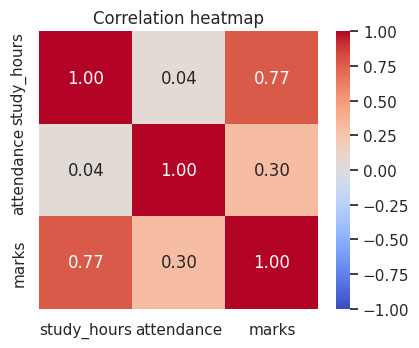

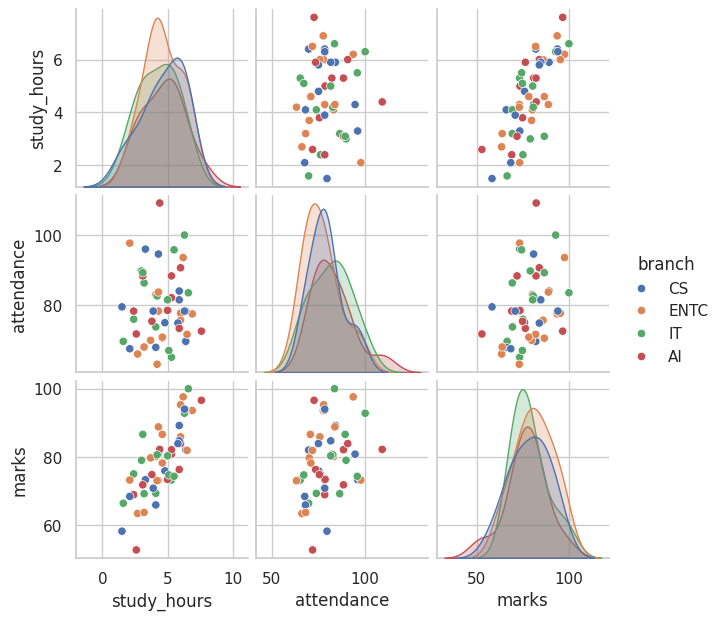

In [15]:
corr = merged[["study_hours", "attendance", "marks"]].corr()
plt.figure(figsize=(4.5, 3.6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation heatmap"); plt.show()

sns.pairplot(merged[["study_hours", "attendance", "marks", "branch"]], hue="branch", height=2.1)
plt.show()

## Summary
| Topic | Key takeaway |
|---|---|
| Functions | `*args`, `**kwargs`, lambda, default args |
| OOP | classes, `__init__`, inheritance, overriding |
| Comprehensions | concise list/dict/set building |
| NumPy | arrays, broadcasting, vectorised ops are fast |
| Pandas | clean → merge → groupby is the core workflow |
| Matplotlib | full control over every element |
| Seaborn | quick statistical plots on DataFrames |